# Lab 3: Histological image classification leveraging Bag Of Features

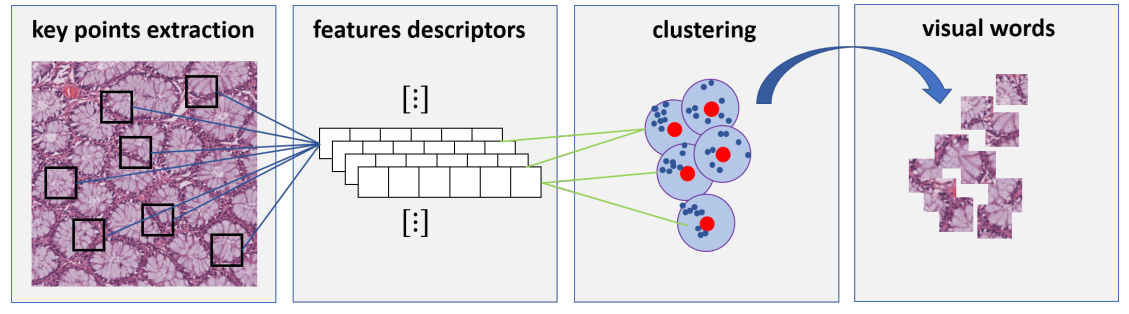

## Import and settings

In [1]:
import os
import cv2
import glob
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [4]:
!git clone https://github.com/frpnz/dataset-BIOSTEC2018.git
ROOTDIR_DATASET = "../notebooks/dataset-BIOSTEC2018/crc_images"

Cloning into 'dataset-BIOSTEC2018'...
Updating files:   1% (240/13501)
Updating files:   2% (271/13501)
Updating files:   3% (406/13501)
Updating files:   4% (541/13501)
Updating files:   4% (565/13501)
Updating files:   5% (676/13501)
Updating files:   6% (811/13501)
Updating files:   7% (946/13501)
Updating files:   7% (948/13501)
Updating files:   8% (1081/13501)
Updating files:   9% (1216/13501)
Updating files:   9% (1344/13501)
Updating files:  10% (1351/13501)
Updating files:  11% (1486/13501)
Updating files:  12% (1621/13501)
Updating files:  12% (1740/13501)
Updating files:  13% (1756/13501)
Updating files:  14% (1891/13501)
Updating files:  15% (2026/13501)
Updating files:  15% (2157/13501)
Updating files:  16% (2161/13501)
Updating files:  17% (2296/13501)
Updating files:  18% (2431/13501)
Updating files:  18% (2559/13501)
Updating files:  19% (2566/13501)
Updating files:  20% (2701/13501)
Updating files:  21% (2836/13501)
Updating files:  21% (2913/13501)
Updating files:  22

## Utils
The well-know function to plot a nice confusion matrix

In [5]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")

Write a class to handle the dataset.
Such class must return a dict with

*   key = class
*   value = list of tuples (image, filepath)

Where image is a numpy array of shape (90, 90, 3). Hence, the images must be resized. See functions in [OpenCV-Python](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html), a library of Python bindings designed to solve computer vision problem.

In [6]:
class Dataset:
    def __init__(self, path):
        self.path = path

    def getFiles(self):
        """
        returns a dict with key = object_name and value = list of tuples (image, filepath)
        """
        image_dict = dict()
        for subdir in glob.glob(f"{self.path}/*/", recursive=False):
            word = os.path.basename(os.path.normpath(subdir))
            image_dict[word] = list()
            for image_file in glob.glob(f"{subdir}/*", recursive=False):
                image = cv2.imread(image_file, 1)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (90, 90))
                image_dict[word].append((image, image_file))
        return image_dict

In [7]:
path_train = os.path.join(ROOTDIR_DATASET, "train")
dataset = Dataset(path_train)
dataset_train = dataset.getFiles()

# Assignment #1: Plot some random images to ensure the images to be correctly loaded.
This should be their aspect.

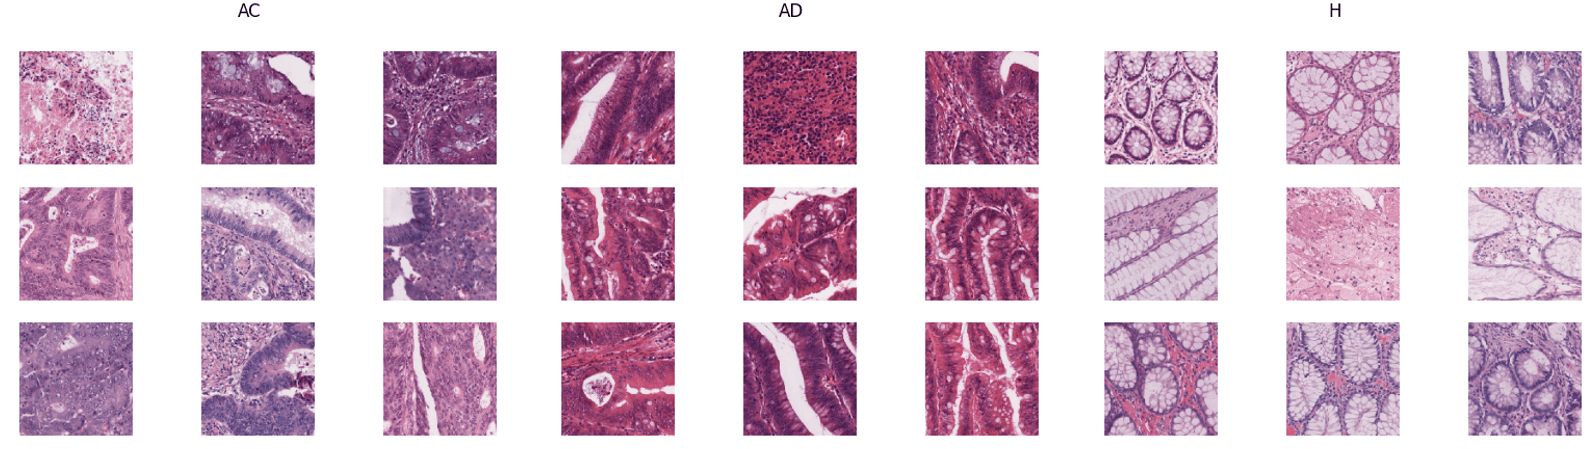

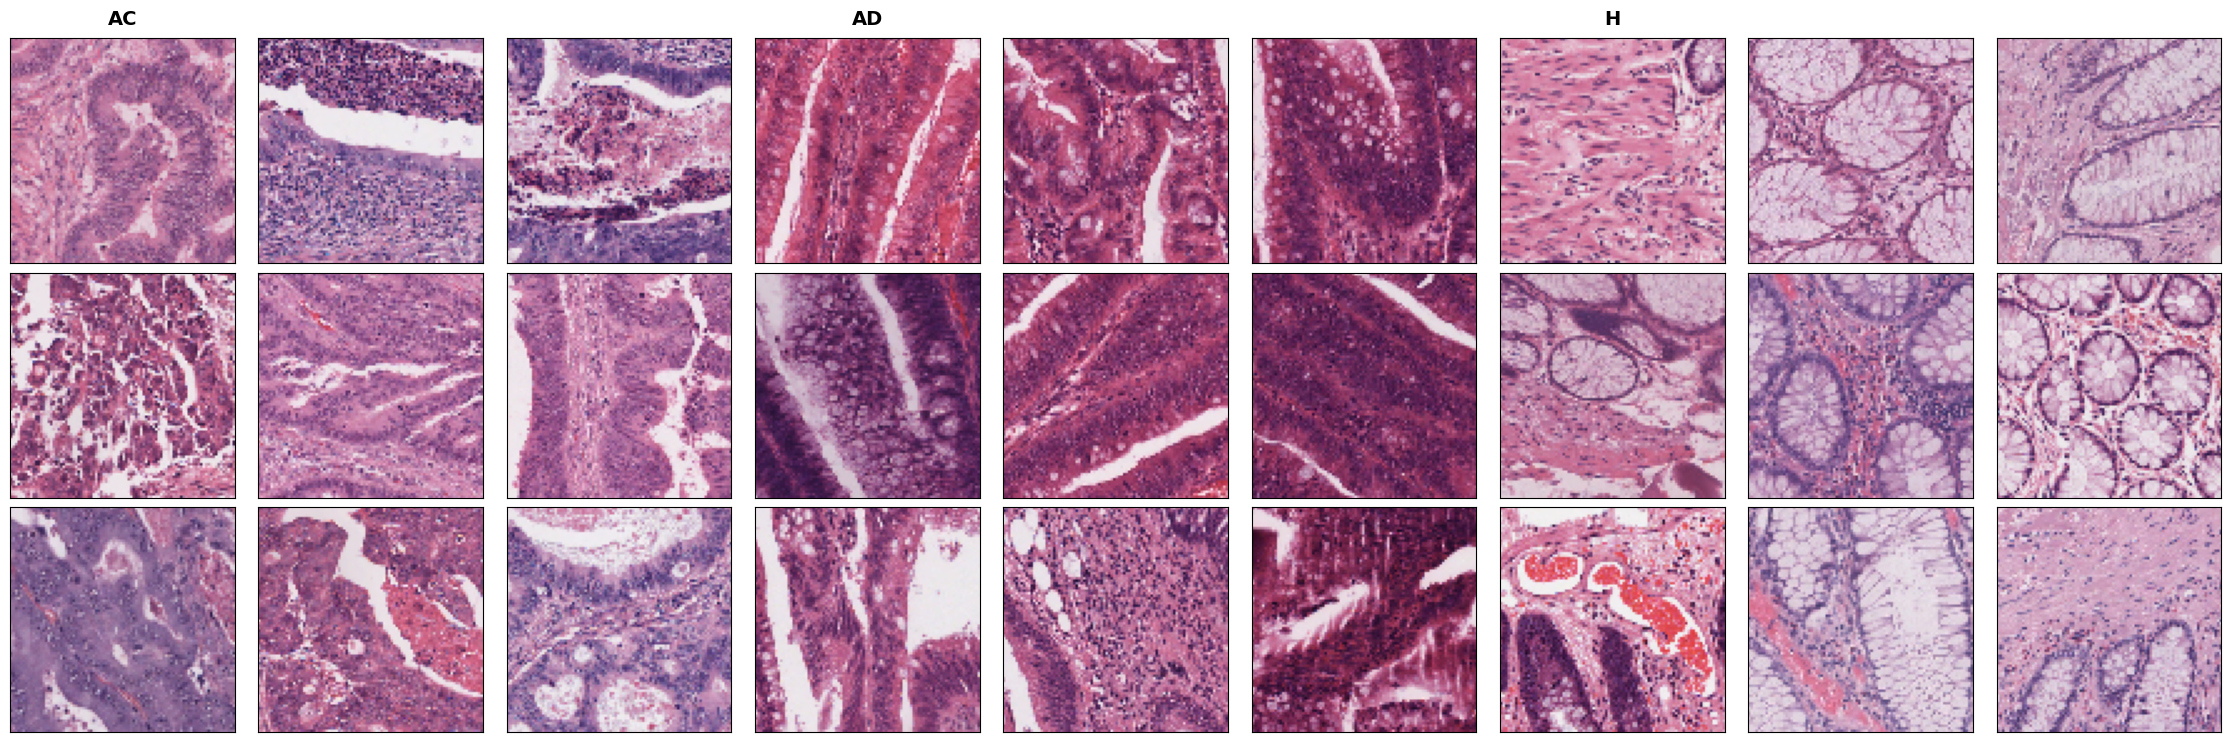

In [ ]:
import matplotlib.pyplot as plt
import random

random.seed(42)

n_rows = 3
n_cols_per_class = 3

classes = sorted(dataset_train.keys())
n_classes = len(classes)

fig, axes = plt.subplots(n_rows, n_cols_per_class * n_classes, figsize=(n_cols_per_class * n_classes * 2.5, n_rows * 2.5))
for cls_idx, cls_name in enumerate(classes):
    images_list = dataset_train[cls_name]
    
    num_samples = min(9, len(images_list))
    samples = random.sample(images_list, num_samples)
    
    for img_idx in range(9):
        row = img_idx // n_cols_per_class
        col_in_class = img_idx % n_cols_per_class
        col_global = cls_idx * n_cols_per_class + col_in_class
        
        ax = axes[row, col_global]
        
        if img_idx < len(samples):
            img = samples[img_idx][0] if isinstance(samples[img_idx], tuple) else samples[img_idx]
            ax.imshow(img)
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        if row == 0 and col_in_class == 0:
            ax.set_title(cls_name, fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

In [15]:
class ImageHelpers:
    def __init__(self):
        self.sift_object = cv2.SIFT_create()

    def gray(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        return gray

    def features(self, image):
        keypoints, descriptors = self.sift_object.detectAndCompute(image, None)
        return [keypoints, descriptors]

Extract SIFT descriptors for all the images. See an example [here](https://vovkos.github.io/doxyrest-showcase/opencv/sphinxdoc/page_tutorial_py_sift_intro.html)

Using SIFT, we detect and extract features inside each image. SIFT through OPENCV returns us a  `m x 128` dimension array, where `m` is the number of features extrapolated. Note that `m changes among different images`, depending on which features are detected. In some extreme cases (specifically when the image resolution is lower than 128x128) I experienced to get no detected features at all for some images.

In [16]:
# extract SIFT Features from each image
class Descriptors:
    def __init__(self, dataset):
        self.dataset = dataset
        self.im_helper = ImageHelpers()

    def GetDescriptors(self):
        labels = list()
        descriptor_list = list()
        name_dict = dict()
        label_count = 0
        for word, imlist in self.dataset.items():
            name_dict[label_count] = word
            for im, filepath in imlist:
                kp, des = self.im_helper.features(im)
                if des is None:
                    print(f"Cannot extract SIFT for {filepath}.")
                    continue
                descriptor_list.append(des)
                labels.append(label_count)
            label_count += 1
        return descriptor_list, labels, name_dict

# Assignment #2: # reshape list into np array of shape K samples x 128 features for sklearn



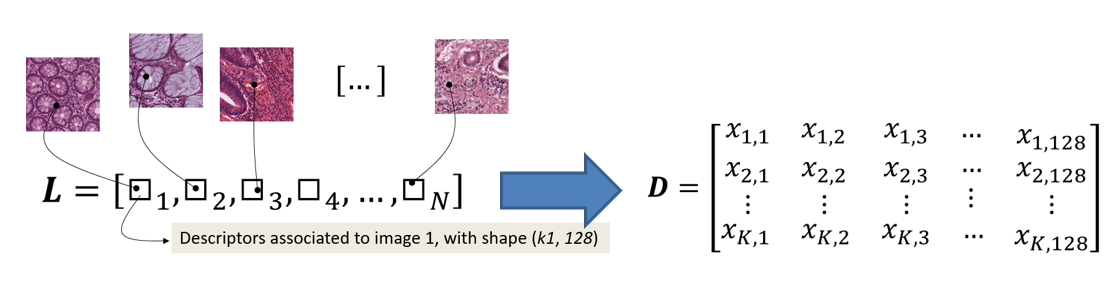

In [22]:
import numpy as np

descriptors = Descriptors(dataset_train)
descriptor_list, labels, name_dict = descriptors.GetDescriptors()
descriptor_array = np.vstack(descriptor_list)

# Assignment #3: Construction of the visual vocabulary by k-means clustering (see [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) implementation)
May require some time depending on the input resolution (~ 6/7 mins for 70x70 RGB images).

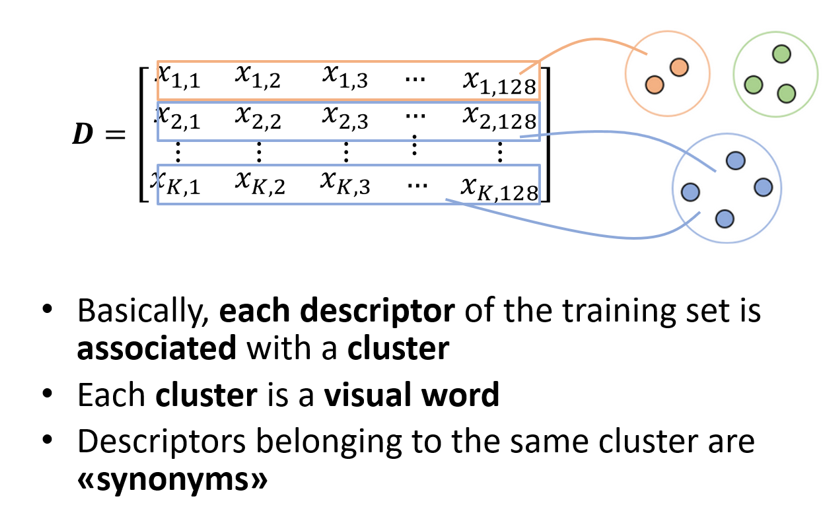

In [20]:
n_clusters = 100
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_pred_train = kmeans.fit_predict(descriptor_array)


# Assignment #4: Build the histogram of the visual words


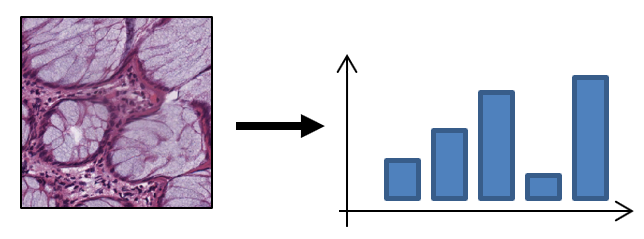

In [25]:
def MakeHistogram(descriptors_list, n_clusters, kmeans_labels):
    histogram = np.zeros((len(descriptors_list), n_clusters), dtype=int)
    idx = 0
    for i, des in enumerate(descriptors_list):
        n_des = len(des)
        if n_des == 0:
            continue
        labels = kmeans_labels[idx:idx+n_des]
        for cluster_idx in labels:
            histogram[i][cluster_idx] += 1
        idx += n_des
    return histogram

## Assignment #4.1: Scale the histogram of the visual words

In [26]:
histogram_train = MakeHistogram(descriptor_list, n_clusters, kmeans_pred_train)
scaler = preprocessing.StandardScaler().fit(histogram_train)
histogram_train_scaled = scaler.transform(histogram_train)

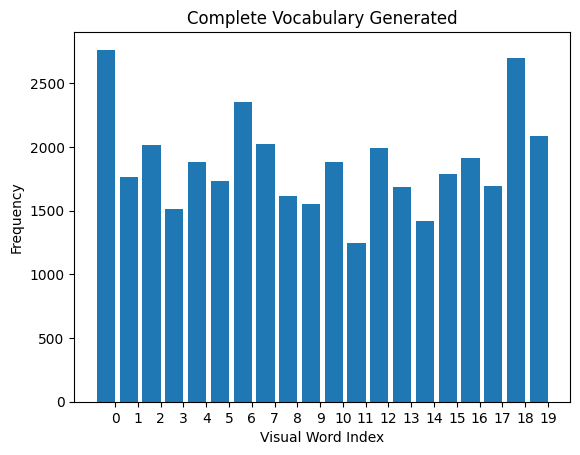

In [27]:
x_scalar = np.arange(20)
y_scalar = np.array([abs(np.sum(histogram_train_scaled[:,h], dtype=np.int32)) for h in range(20)])
plt.bar(x_scalar, y_scalar)
plt.xlabel("Visual Word Index")
plt.ylabel("Frequency")
plt.title("Complete Vocabulary Generated")
plt.xticks(x_scalar + 0.4, x_scalar)
plt.show()

# Assignment #5: Train and then test an SVM on the histogram of the visual words

In [34]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(histogram_train_scaled, labels)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Test the model

In [35]:
preds = svm.predict(histogram_train_scaled)
